# 01 - Exploração Inicial dos Dados e Primeira Rede

**TCC MBA USP/ECA - Redes e Guerras Mundiais**

Este notebook realiza:
1. Exploração dos datasets COW (Correlates of War)
2. Construção da primeira rede de alianças (Pré-WWI: 1890-1914)
3. Cálculo de métricas de centralidade
4. Visualização da rede

## Setup Inicial

In [1]:
# Imports
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path

# Adicionar src ao path
sys.path.insert(0, str(Path.cwd().parent / 'src'))

# Imports do projeto
from etl.load_cow import load_alliances, load_nmc, load_trade
from etl.transform import prepare_alliance_edges, filter_by_cinc
from network.build_network import build_alliance_network
from network.metrics import calculate_centrality_metrics, calculate_global_metrics, calculate_community_metrics

# Configurações
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

# Constantes
PRE_WWI_START = 1890
PRE_WWI_END = 1914
CINC_THRESHOLD = 0.01  # 1% do poder mundial

print("Setup concluído!")

Setup concluído!


## 1. Carregar e Explorar Dados de Alianças

In [2]:
# Carregar todas as alianças
df_alliances_all = load_alliances()
print(f"Total de registros de alianças (1816-2012): {len(df_alliances_all)}")
print(f"\nColunas disponíveis:")
print(df_alliances_all.columns.tolist())

Total de registros de alianças (1816-2012): 3222

Colunas disponíveis:
['version4id', 'ccode1', 'state_name1', 'ccode2', 'state_name2', 'dyad_st_day', 'dyad_st_month', 'dyad_st_year', 'dyad_end_day', 'dyad_end_month', 'dyad_end_year', 'left_censor', 'right_censor', 'defense', 'neutrality', 'nonaggression', 'entente', 'asymmetric', 'version']


In [3]:
# Primeiros registros
df_alliances_all.head(10)

,version4id,ccode1,state_name1,ccode2,state_name2,dyad_st_day,dyad_st_month,dyad_st_year,dyad_end_day,dyad_end_month,dyad_end_year,left_censor,right_censor,defense,neutrality,nonaggression,entente,asymmetric,version
0,1,200,United Kingdom,235,Portugal,1,1,1816,NaN,NaN,NaN,1,1,1,0,1,0.0,0,4.1
1,2,200,United Kingdom,380,Sweden,1,1,1816,15.0,2.0,1911.0,1,0,0,0,0,1.0,0,4.1
2,3,240,Hanover,245,Bavaria,1,1,1838,15.0,3.0,1848.0,0,0,1,0,1,1.0,0,4.1
3,3,240,Hanover,245,Bavaria,29,11,1850,15.0,6.0,1866.0,0,0,1,0,1,1.0,0,4.1
4,3,240,Hanover,255,Germany,1,1,1838,15.0,3.0,1848.0,0,0,1,0,1,1.0,0,4.1
5,3,240,Hanover,255,Germany,29,11,1850,15.0,6.0,1866.0,0,0,1,0,1,1.0,0,4.1
6,3,240,Hanover,267,Baden,1,1,1838,15.0,3.0,1848.0,0,0,1,0,1,1.0,0,4.1
7,3,240,Hanover,267,Baden,29,11,1850,15.0,6.0,1866.0,0,0,1,0,1,1.0,0,4.1
8,3,240,Hanover,269,Saxony,1,1,1838,15.0,3.0,1848.0,0,0,1,0,1,1.0,0,4.1
9,3,240,Hanover,269,Saxony,29,11,1850,15.0,6.0,1866.0,0,0,1,0,1,1.0,0,4.1


In [4]:
# Informações sobre o dataset
df_alliances_all.info()

<class 'pandas.DataFrame'>
RangeIndex: 3222 entries, 0 to 3221
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   version4id      3222 non-null   int64  
 1   ccode1          3222 non-null   int64  
 2   state_name1     3222 non-null   str    
 3   ccode2          3222 non-null   int64  
 4   state_name2     3222 non-null   str    
 5   dyad_st_day     3222 non-null   int64  
 6   dyad_st_month   3222 non-null   int64  
 7   dyad_st_year    3222 non-null   int64  
 8   dyad_end_day    1626 non-null   float64
 9   dyad_end_month  1626 non-null   float64
 10  dyad_end_year   1626 non-null   float64
 11  left_censor     3222 non-null   int64  
 12  right_censor    3222 non-null   int64  
 13  defense         3222 non-null   int64  
 14  neutrality      3222 non-null   int64  
 15  nonaggression   3222 non-null   int64  
 16  entente         3221 non-null   float64
 17  asymmetric      3222 non-null   int64  
 18 

### 1.1 Tipos de Aliança

O COW classifica alianças em 4 tipos:
- **Defense**: Pacto de defesa mútua (mais forte)
- **Neutrality**: Pacto de neutralidade
- **Nonaggression**: Pacto de não-agressão
- **Entente**: Entendimento/consulta (mais fraco)

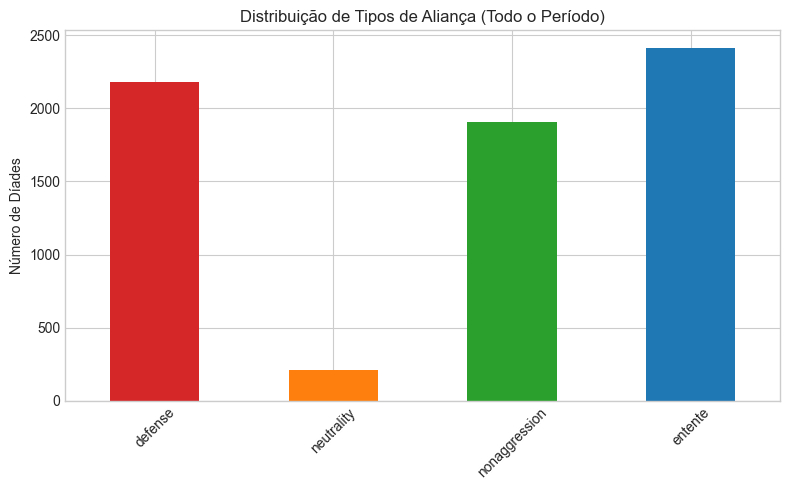

In [5]:
# Distribuição geral por tipo de aliança
alliance_types = ['defense', 'neutrality', 'nonaggression', 'entente']
type_counts_all = df_alliances_all[alliance_types].sum()

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4']
type_counts_all.plot(kind='bar', color=colors, ax=ax)
ax.set_title('Distribuição de Tipos de Aliança (Todo o Período)', fontsize=12)
ax.set_ylabel('Número de Díades')
ax.set_xticklabels(alliance_types, rotation=45)
plt.tight_layout()
plt.show()

## 2. Filtrar para Janela Pré-WWI (1890-1914)

In [6]:
# Carregar alianças do período
df_alliances = load_alliances(start_year=PRE_WWI_START, end_year=PRE_WWI_END)
print(f"Alianças ativas no período {PRE_WWI_START}-{PRE_WWI_END}: {len(df_alliances)}")

# Distribuição por tipo no período
type_counts = df_alliances[alliance_types].sum()
print(f"\nDistribuição por tipo:")
for t in alliance_types:
    print(f"  {t}: {int(type_counts[t])}")

Alianças ativas no período 1890-1914: 62

Distribuição por tipo:
  defense: 25
  neutrality: 15
  nonaggression: 18
  entente: 29


## 3. Carregar Dados de Capacidades Nacionais (NMC)

O índice **CINC** (Composite Index of National Capability) mede a capacidade material de um Estado, considerando:
- Gastos militares
- Pessoal militar
- Produção de ferro/aço
- Consumo de energia
- População total
- População urbana

In [7]:
# Carregar NMC do período
df_nmc = load_nmc(start_year=PRE_WWI_START, end_year=PRE_WWI_END)
print(f"Registros NMC no período: {len(df_nmc)}")
print(f"\nColunas: {df_nmc.columns.tolist()}")

Registros NMC no período: 1049

Colunas: ['stateabb', 'ccode', 'year', 'milex', 'milper', 'irst', 'pec', 'tpop', 'upop', 'cinc', 'version']


In [8]:
# Top 15 países por CINC médio no período
avg_cinc = df_nmc.groupby(['ccode', 'stateabb'])['cinc'].mean().reset_index()
avg_cinc = avg_cinc.sort_values('cinc', ascending=False)
avg_cinc['cinc_pct'] = (avg_cinc['cinc'] * 100).round(2)

print("Top 15 Potências por CINC médio (1890-1914):")
print("="*50)
top15 = avg_cinc.head(15)
for i, row in top15.iterrows():
    print(f"{row['stateabb']:5} | CINC: {row['cinc_pct']:5.2f}%")

Top 15 Potências por CINC médio (1890-1914):
USA   | CINC: 19.60%
UKG   | CINC: 14.86%
GMY   | CINC: 13.29%
CHN   | CINC: 12.83%
RUS   | CINC: 11.29%
FRN   | CINC:  7.87%
AUH   | CINC:  4.53%
JPN   | CINC:  3.17%
ITA   | CINC:  3.09%
TUR   | CINC:  1.82%
SPN   | CINC:  1.59%
BEL   | CINC:  1.50%
BRA   | CINC:  0.98%
SWD   | CINC:  0.84%
NTH   | CINC:  0.73%


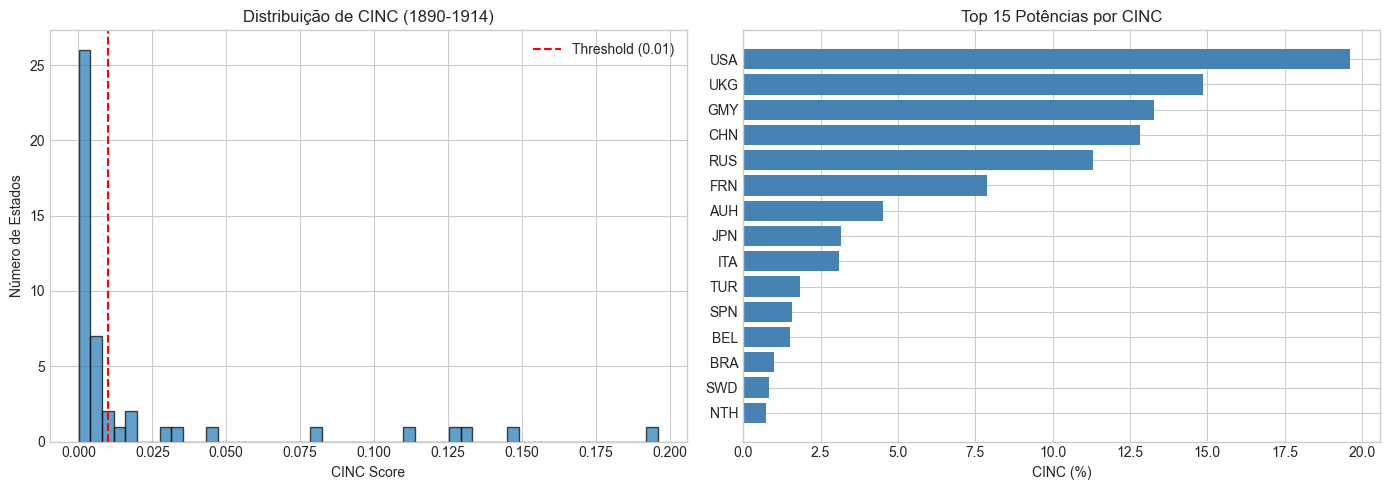

In [9]:
# Visualizar distribuição de CINC
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(avg_cinc['cinc'], bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(x=CINC_THRESHOLD, color='red', linestyle='--', label=f'Threshold ({CINC_THRESHOLD})')
axes[0].set_xlabel('CINC Score')
axes[0].set_ylabel('Número de Estados')
axes[0].set_title('Distribuição de CINC (1890-1914)')
axes[0].legend()

# Top 15 barras
axes[1].barh(range(15), top15['cinc_pct'].values, color='steelblue')
axes[1].set_yticks(range(15))
axes[1].set_yticklabels(top15['stateabb'].values)
axes[1].invert_yaxis()
axes[1].set_xlabel('CINC (%)')
axes[1].set_title('Top 15 Potências por CINC')

plt.tight_layout()
plt.show()

## 4. Filtrar Alianças por CINC

Para focar nas grandes potências, filtramos apenas Estados com CINC >= 1% do poder mundial.

In [10]:
# Aplicar filtro CINC
df_alliances_filtered = filter_by_cinc(df_alliances, df_nmc, threshold=CINC_THRESHOLD)
print(f"Alianças após filtro CINC >= {CINC_THRESHOLD}: {len(df_alliances_filtered)}")

# Ver países únicos
countries = set(df_alliances_filtered['state_name1'].unique()) | set(df_alliances_filtered['state_name2'].unique())
print(f"\nPaíses incluídos ({len(countries)}):")
print(sorted(countries))

Alianças após filtro CINC >= 0.01: 36

Países incluídos (11):
['Austria-Hungary', 'China', 'France', 'Germany', 'Italy', 'Japan', 'Russia', 'Spain', 'Turkey', 'United Kingdom', 'United States of America']


## 5. Construir Rede de Alianças

In [11]:
# Preparar arestas (remove duplicatas, mantém aliança mais forte)
edges = prepare_alliance_edges(df_alliances_filtered)
print(f"Arestas únicas: {len(edges)}")
print(f"\nAmostra de arestas:")
edges.head(10)

Arestas únicas: 21

Amostra de arestas:


,source,target,source_name,target_name,weight,alliance_type
226,255,300,Germany,Austria-Hungary,4,defense
262,255,365,Germany,Russia,4,defense
257,200,740,United Kingdom,Japan,4,defense
256,365,710,Russia,China,4,defense
254,220,365,France,Russia,4,defense
284,255,640,Germany,Turkey,4,defense
235,255,325,Germany,Italy,4,defense
237,300,325,Austria-Hungary,Italy,4,defense
258,220,325,France,Italy,3,neutrality
261,300,365,Austria-Hungary,Russia,3,neutrality


In [12]:
# Construir grafo
G = build_alliance_network(edges)

print("=" * 50)
print("REDE DE ALIANÇAS PRÉ-WWI (1890-1914)")
print("=" * 50)
print(f"Nós (Estados): {G.number_of_nodes()}")
print(f"Arestas (Alianças): {G.number_of_edges()}")

REDE DE ALIANÇAS PRÉ-WWI (1890-1914)
Nós (Estados): 11
Arestas (Alianças): 21


## 6. Métricas Globais da Rede

In [13]:
# Calcular métricas globais
global_metrics = calculate_global_metrics(G)

print("\nMÉTRICAS GLOBAIS")
print("-" * 40)
for metric, value in global_metrics.items():
    if isinstance(value, float):
        print(f"{metric:30} {value:.4f}")
    else:
        print(f"{metric:30} {value}")


MÉTRICAS GLOBAIS
----------------------------------------
num_nodes                      11
num_edges                      21
density                        0.3818
is_connected                   True
num_components                 1
average_degree                 3.8182
average_clustering             0.3636
diameter                       4
average_path_length            1.8727
radius                         2


### Interpretação das Métricas Globais

- **Densidade**: Proporção de alianças existentes vs. possíveis. Valores altos indicam sistema mais interconectado.
- **Componentes**: Número de grupos desconectados. Idealmente 1 (todos conectados).
- **Diâmetro**: Maior "distância" entre quaisquer dois Estados via alianças.
- **Clustering**: Tendência a formar triângulos (meus aliados também são aliados entre si).

## 7. Métricas de Centralidade por Estado

In [14]:
# Calcular métricas de centralidade
centrality_df = calculate_centrality_metrics(G)

print("\nRANKING DE CENTRALIDADE")
print("=" * 80)
display_cols = ['name', 'degree', 'degree_centrality', 'betweenness_centrality', 'closeness_centrality']
centrality_df[display_cols].round(4)


RANKING DE CENTRALIDADE


,name,degree,degree_centrality,betweenness_centrality,closeness_centrality
node,,,,,
365,Russia,6,0.6,0.3759,0.7143
325,Italy,6,0.6,0.0574,0.6667
255,Germany,5,0.5,0.2111,0.6250
300,Austria-Hungary,5,0.5,0.0370,0.6250
200,United Kingdom,5,0.5,0.1167,0.5882
230,Spain,5,0.5,0.0352,0.5882
220,France,4,0.4,0.0222,0.5556
740,Japan,3,0.3,0.2111,0.5556
710,China,1,0.1,0.0000,0.4348


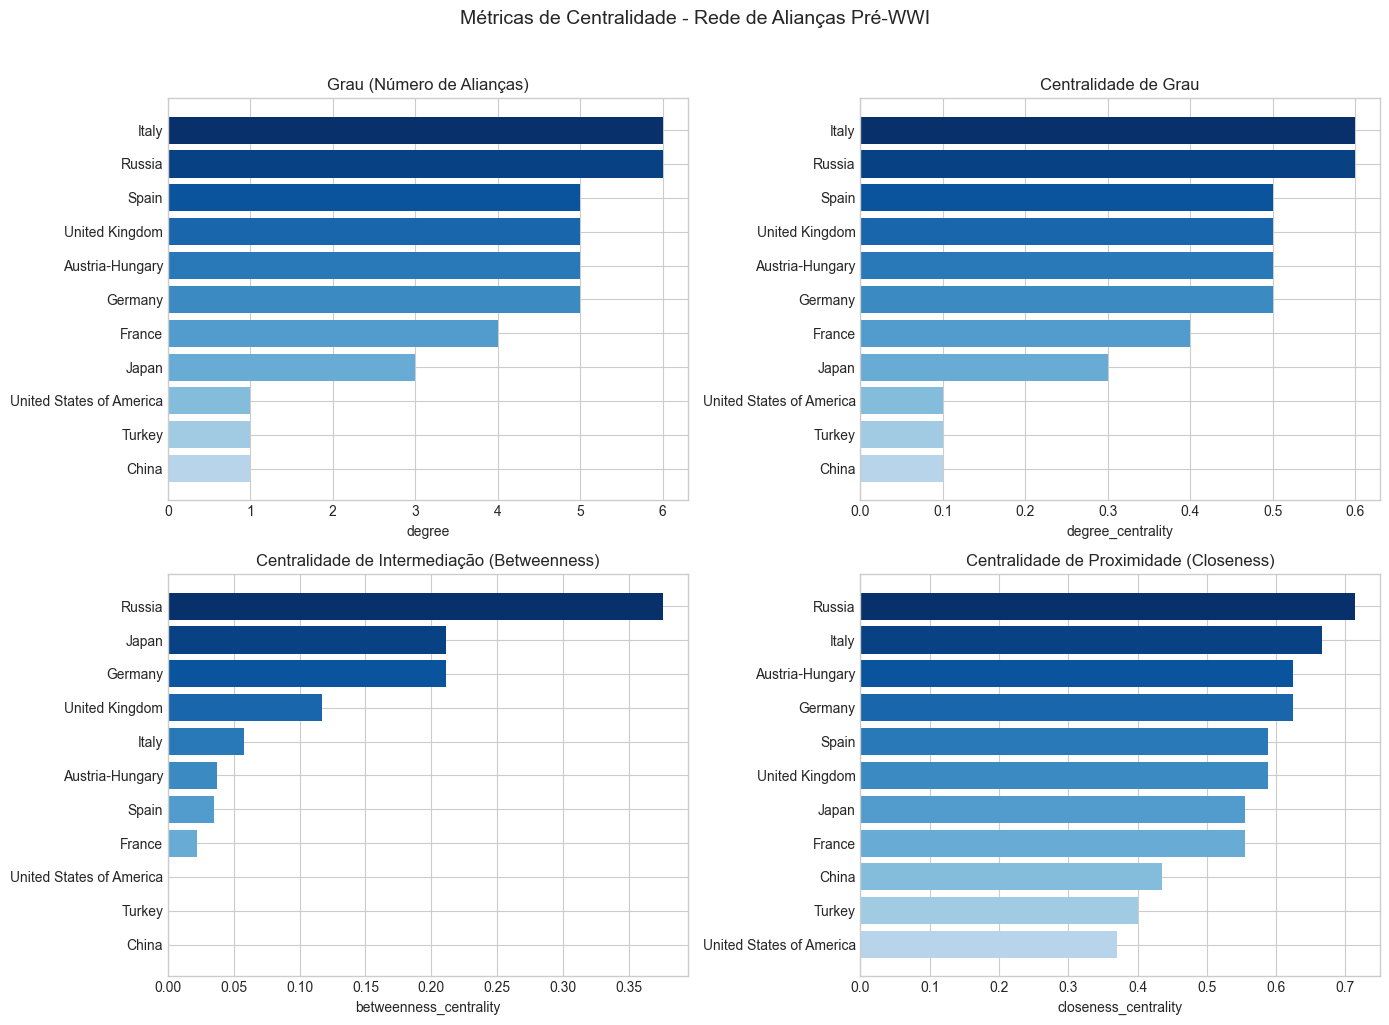

In [15]:
# Visualizar centralidades
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics_to_plot = [
    ('degree', 'Grau (Número de Alianças)'),
    ('degree_centrality', 'Centralidade de Grau'),
    ('betweenness_centrality', 'Centralidade de Intermediação (Betweenness)'),
    ('closeness_centrality', 'Centralidade de Proximidade (Closeness)')
]

for ax, (metric, title) in zip(axes.flatten(), metrics_to_plot):
    data = centrality_df.sort_values(metric, ascending=True)
    colors = plt.cm.Blues(np.linspace(0.3, 1, len(data)))
    ax.barh(data['name'], data[metric], color=colors)
    ax.set_xlabel(metric)
    ax.set_title(title)

plt.suptitle('Métricas de Centralidade - Rede de Alianças Pré-WWI', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Interpretação das Centralidades

- **Degree (Grau)**: Número de alianças diretas. Estados com alto grau são "hubs" diplomáticos.
- **Betweenness**: Estados que servem de "ponte" entre outros. Alta betweenness = poder de intermediação.
- **Closeness**: Quão "próximo" um Estado está de todos os outros via alianças.

## 8. Detecção de Comunidades

In [16]:
# Instalar python-louvain se necessário
try:
    import community as community_louvain
except ImportError:
    !pip install python-louvain
    import community as community_louvain

# Detectar comunidades
comm_results = calculate_community_metrics(G)

print(f"Número de comunidades detectadas: {comm_results['num_communities']}")
print(f"Modularidade: {comm_results['modularity']:.4f}")
print(f"\nTamanho das comunidades: {comm_results['community_sizes']}")

Número de comunidades detectadas: 3
Modularidade: 0.2472

Tamanho das comunidades: [5, 3, 3]


In [17]:
# Mostrar membros de cada comunidade
partition = comm_results['partition']
communities = {}
for node, comm_id in partition.items():
    name = G.nodes[node].get('name', str(node))
    if comm_id not in communities:
        communities[comm_id] = []
    communities[comm_id].append(name)

print("\nCOMUNIDADES DETECTADAS (possíveis blocos)")
print("=" * 50)
for comm_id, members in sorted(communities.items()):
    print(f"\nComunidade {comm_id + 1}:")
    print(f"  {', '.join(sorted(members))}")


COMUNIDADES DETECTADAS (possíveis blocos)

Comunidade 1:
  Austria-Hungary, Germany, Italy, Spain, Turkey

Comunidade 2:
  Japan, United Kingdom, United States of America

Comunidade 3:
  China, France, Russia


## 9. Visualização da Rede

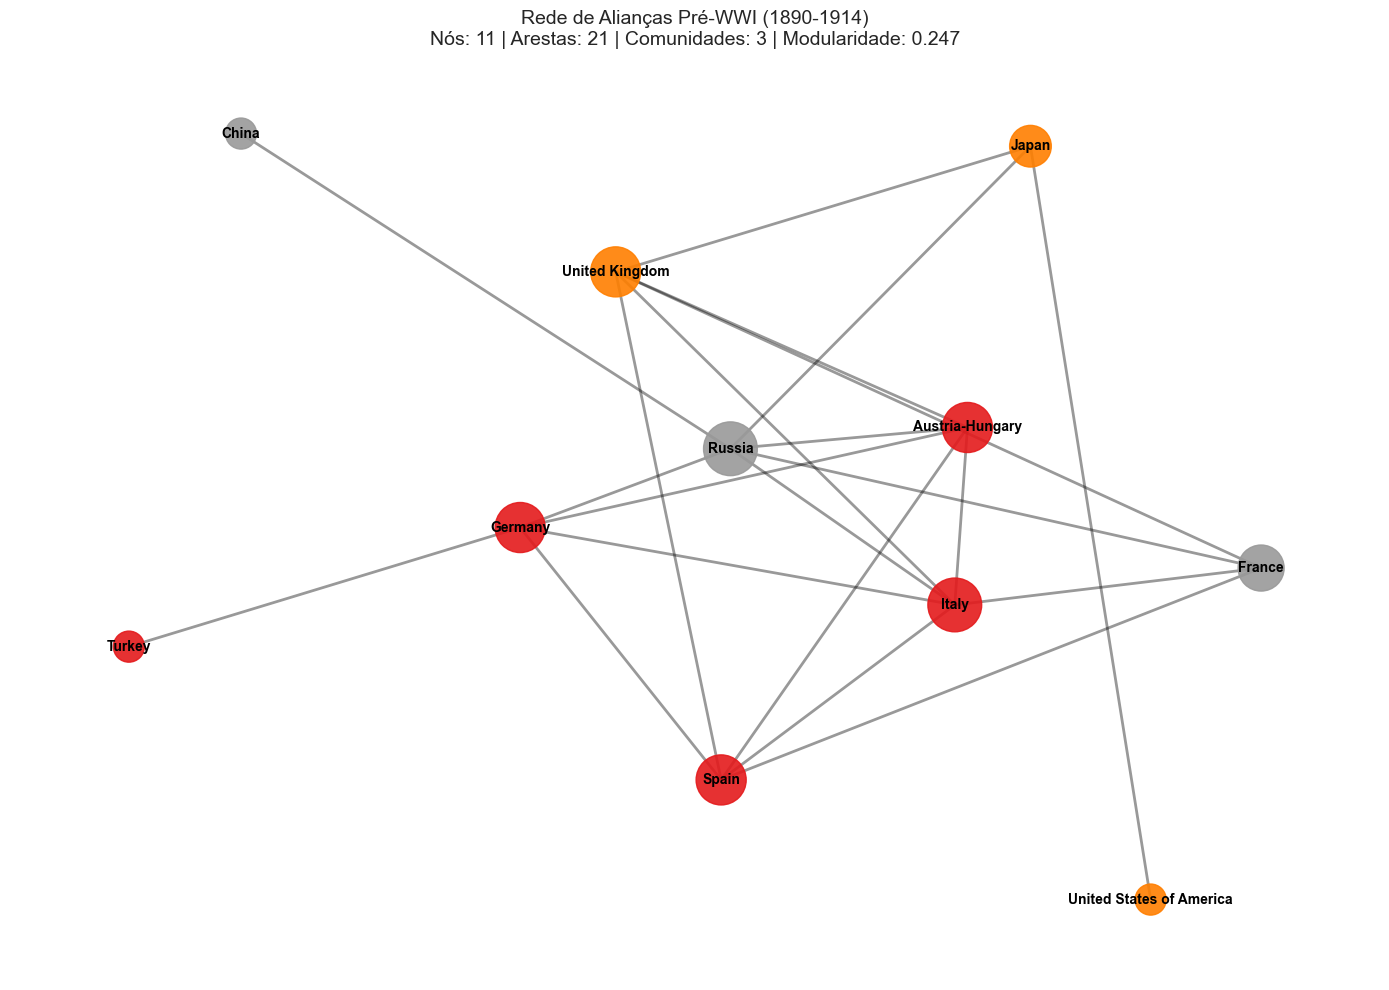


Gráfico salvo em: data/output/rede_aliancas_pre_wwi.png


In [18]:
# Visualização com comunidades
fig, ax = plt.subplots(figsize=(14, 10))

# Layout
pos = nx.spring_layout(G, k=2, seed=42)

# Cores por comunidade
node_colors = [partition[node] for node in G.nodes()]

# Tamanhos por grau
degrees = dict(G.degree())
node_sizes = [300 + degrees[node] * 200 for node in G.nodes()]

# Desenhar
nx.draw_networkx_edges(G, pos, alpha=0.4, width=2, ax=ax)
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, 
                       cmap=plt.cm.Set1, alpha=0.9, ax=ax)

# Labels
labels = nx.get_node_attributes(G, 'name')
nx.draw_networkx_labels(G, pos, labels, font_size=10, font_weight='bold', ax=ax)

ax.set_title(f'Rede de Alianças Pré-WWI ({PRE_WWI_START}-{PRE_WWI_END})\n'
             f'Nós: {G.number_of_nodes()} | Arestas: {G.number_of_edges()} | '
             f'Comunidades: {comm_results["num_communities"]} | Modularidade: {comm_results["modularity"]:.3f}',
             fontsize=14)
ax.axis('off')

plt.tight_layout()
plt.savefig('../data/output/rede_aliancas_pre_wwi.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nGráfico salvo em: data/output/rede_aliancas_pre_wwi.png")

## 10. Exportar para Gephi

In [19]:
from visualization.gephi_export import export_to_gexf

# Adicionar comunidade como atributo dos nós
for node in G.nodes():
    G.nodes[node]['community'] = partition[node]

# Exportar
output_path = '../data/output/rede_aliancas_pre_wwi.gexf'
export_to_gexf(G, output_path, include_metrics=True)

print(f"\nArquivo GEXF salvo! Abra no Gephi para visualização interativa.")

Grafo exportado para: ../data/output/rede_aliancas_pre_wwi.gexf

Arquivo GEXF salvo! Abra no Gephi para visualização interativa.


## 11. Resumo e Próximos Passos

### Principais Achados

1. **Rede conectada**: Todos os Estados estão ligados direta ou indiretamente
2. **Estados centrais**: Rússia e Itália têm mais alianças (alto degree)
3. **Intermediários**: Alemanha e Japão têm alta betweenness (conectam diferentes grupos)
4. **Comunidades**: Identificados possíveis blocos geopolíticos

### Próximos Passos

- [ ] Construir rede Pré-WWII (1925-1939) para comparação
- [ ] Adicionar camada de comércio bilateral
- [ ] Adicionar camada de disputas militarizadas (MIDs)
- [ ] Análise de robustez (variar threshold CINC)
- [ ] Comparação estatística entre períodos

In [ ]:
# Salvar métricas em CSV
centrality_df.to_csv('../data/output/metricas_centralidade_pre_wwi.csv')
print("Métricas salvas em: data/output/metricas_centralidade_pre_wwi.csv")